In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [7]:
DATA_PATH = "online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


The dataset contains session-level behavioral data from an e-commerce website. Each row represents a user session and the target variable "Revenue" indicates whether a purchase occurred or not.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [9]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [10]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

The dataset contains no missing values, meaning no imputation is required before modeling.

The features include both numerical behavioral metrics and categorical contextual variables such as Month and VisitorType.

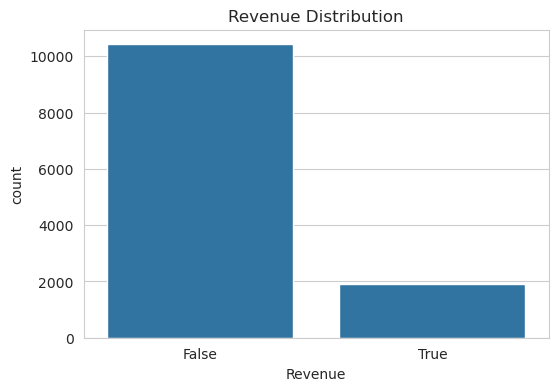

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

In [11]:
#Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Revenue", data=df)

plt.title("Revenue Distribution")
plt.show()

df["Revenue"].value_counts(normalize=True)

The dataset is highly imbalanced:
Approximately 85% of sessions do not result in purchases while only
about 15% generate revenue.

This suggests that accuracy alone will not be a reliable evaluation metric for modeling. Metrics such as ROC-AUC, Recall, and F1-score will be more appropriate.

In [12]:
#Feature type identification
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").drop(columns=["Revenue"]).columns.tolist()

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

Categorical Features: ['Month', 'VisitorType']
Numerical Features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']


The dataset contains a mix of categorical and numerical features.

Categorical features such as Month and VisitorType describe session context, while numerical variables capture behavioral engagement.

Categorical variables will require encoding before training machine learning models.

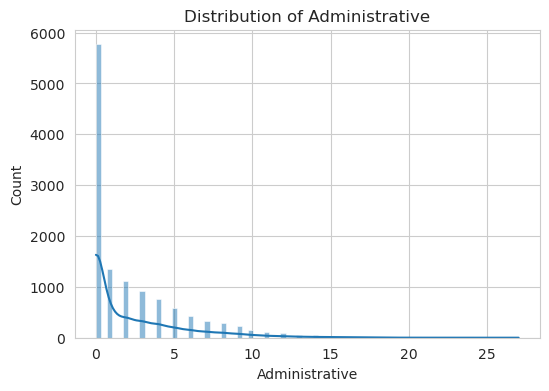

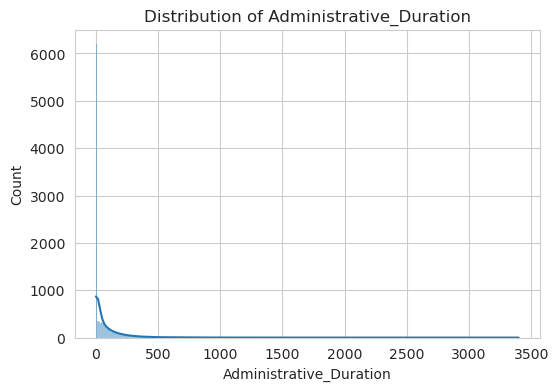

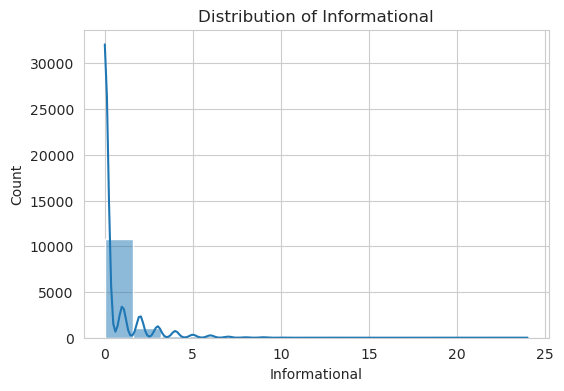

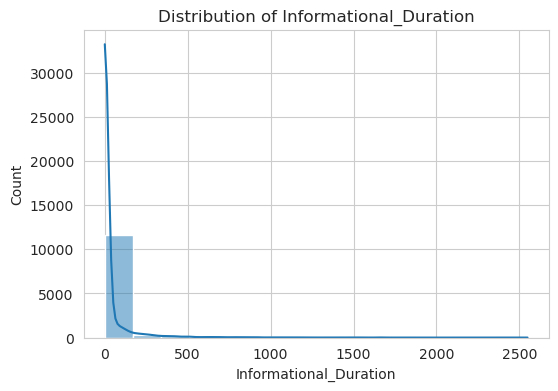

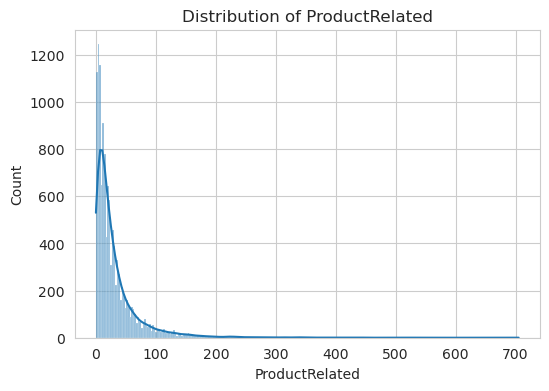

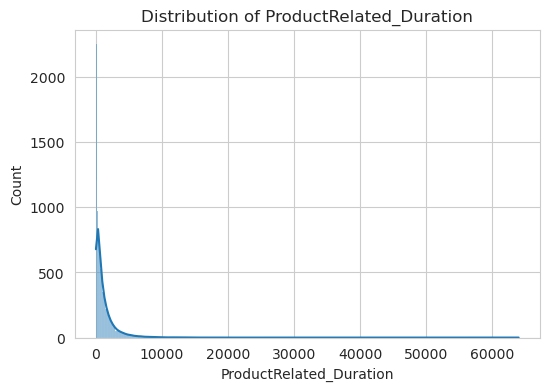

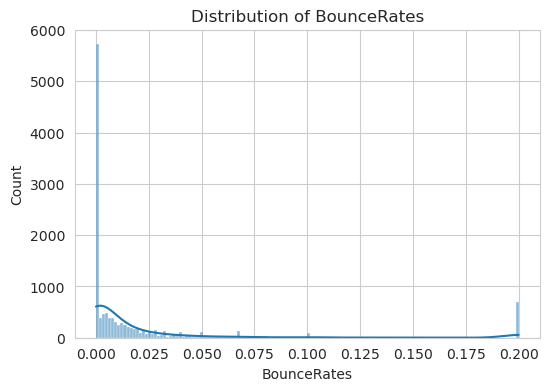

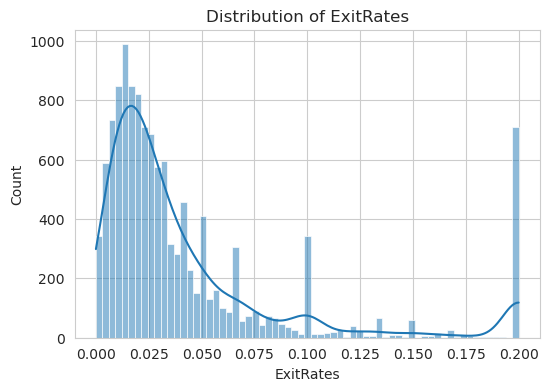

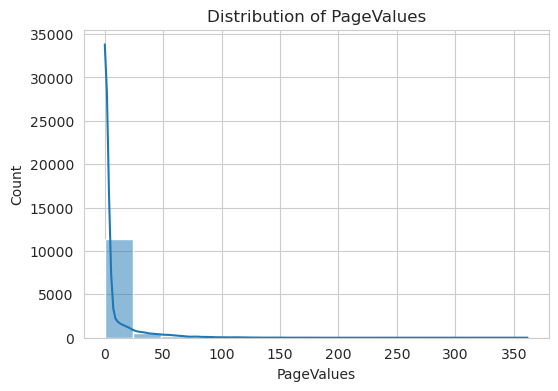

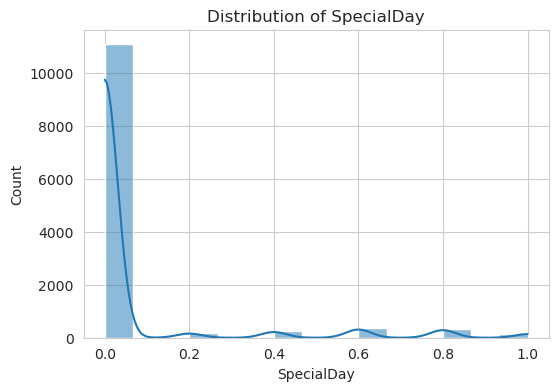

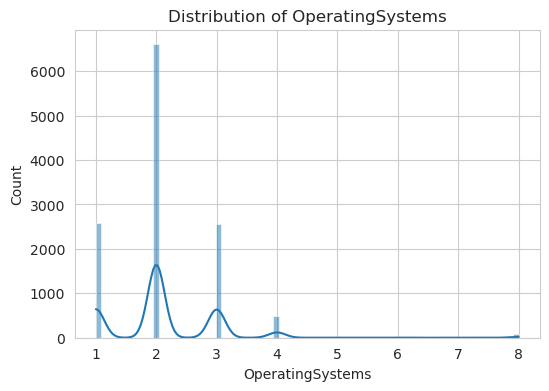

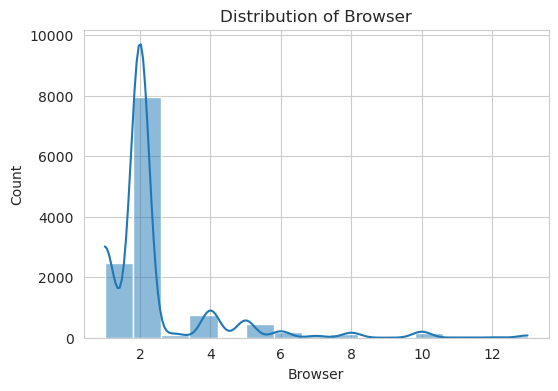

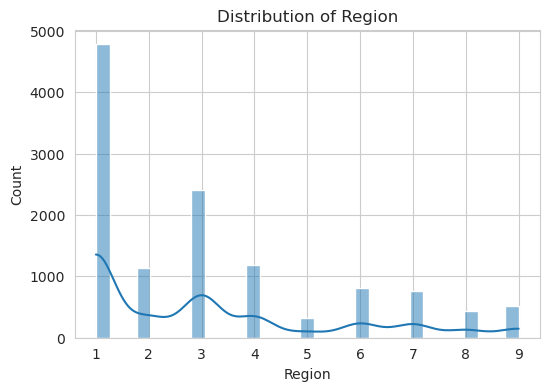

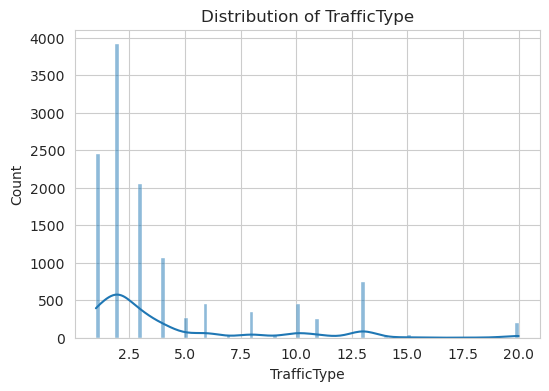

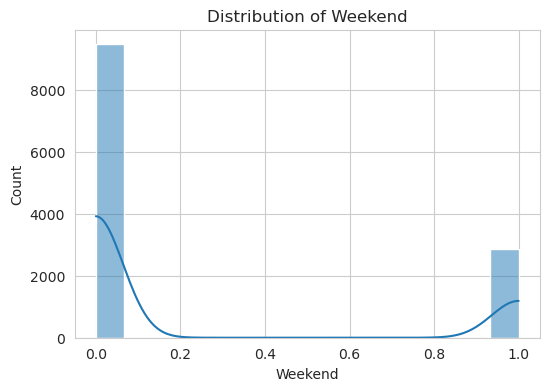

In [13]:
#Numerical Feature Distribution
for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.show()

Several numerical features such as ProductRelated_Duration and PageValues show highly right-skewed distributions.

This indicates that most users have short sessions while a small number of users exhibit very long browsing durations.

Tree-based models such as Random Forest and XGBoost are well-suited for handling skewed distributions.

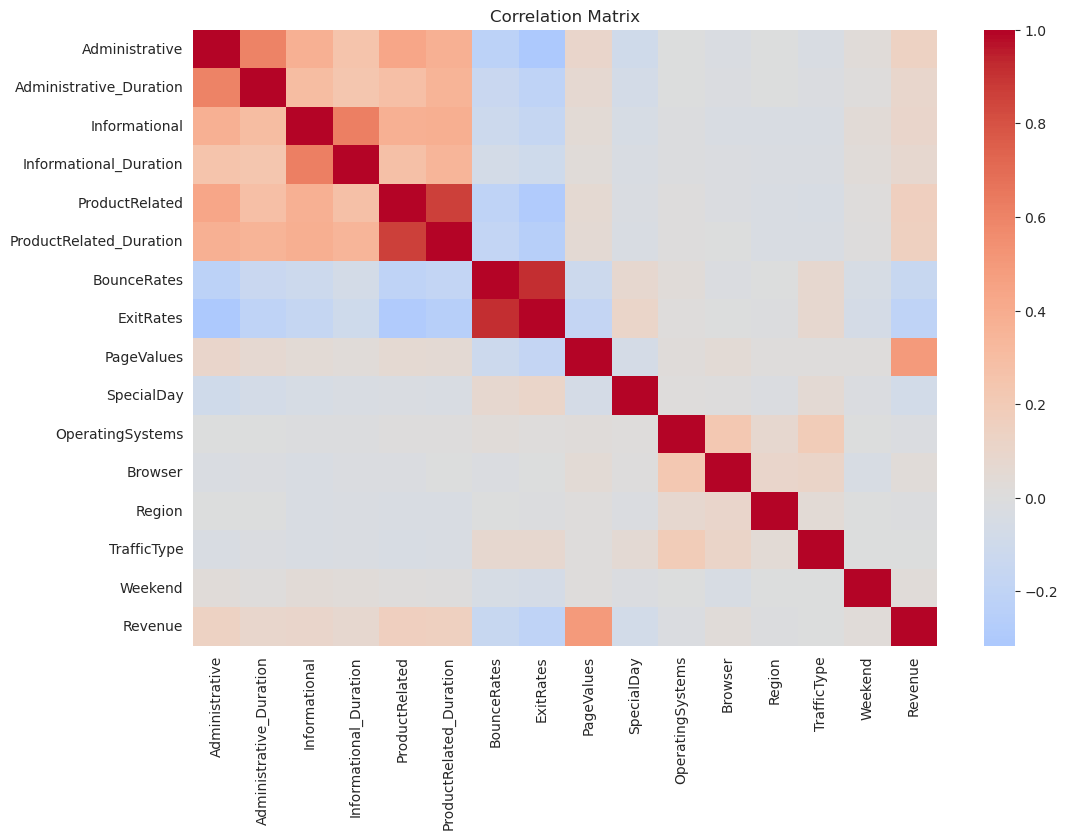

In [14]:
#Correlation Analysis
plt.figure(figsize=(12,8))

corr = df[numerical_cols + ["Revenue"]].corr()

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

PageValues shows a strong positive correlation with Revenue, suggesting
that sessions generating higher page values are more likely to result
in purchases.

BounceRates and ExitRates exhibit negative relationships with Revenue,
indicating that users who leave pages quickly are less likely to
complete a purchase.

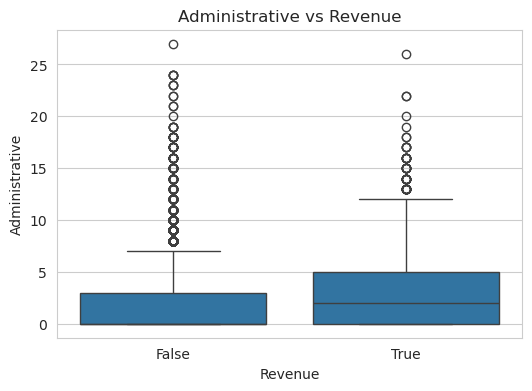

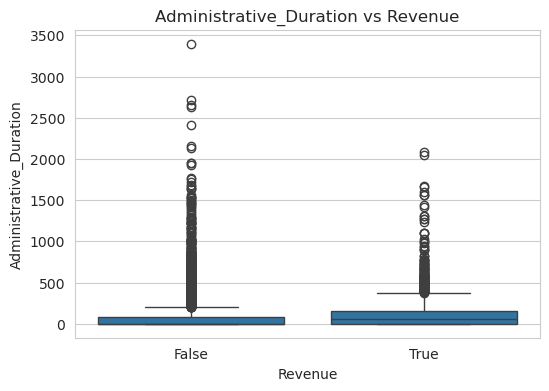

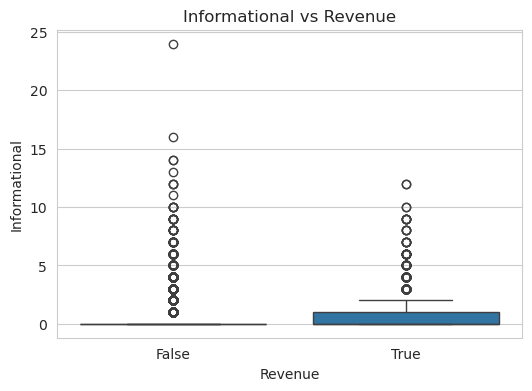

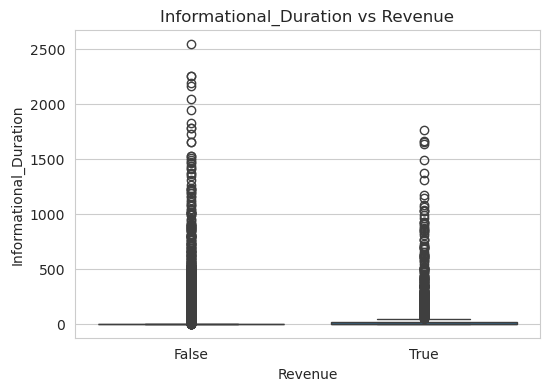

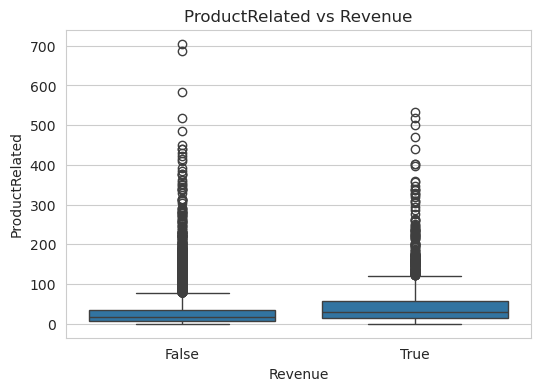

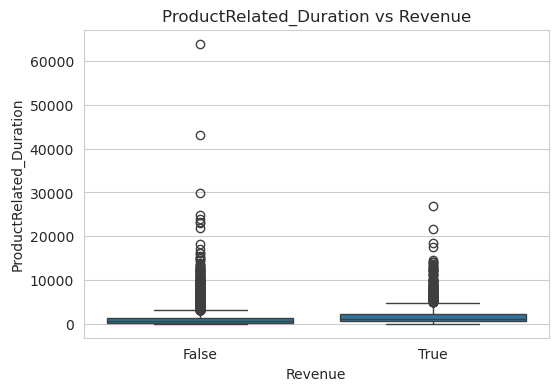

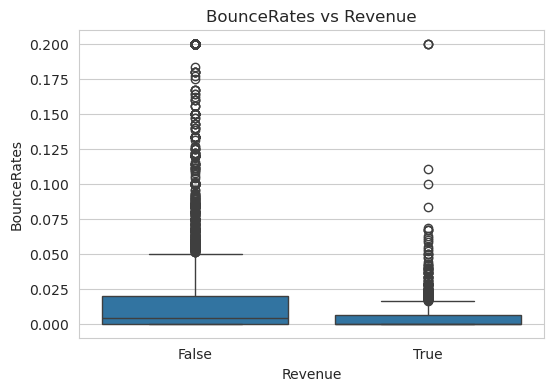

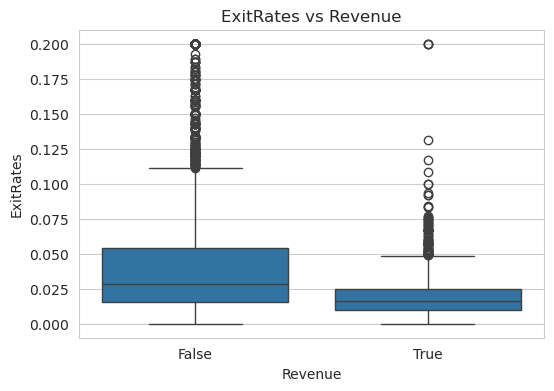

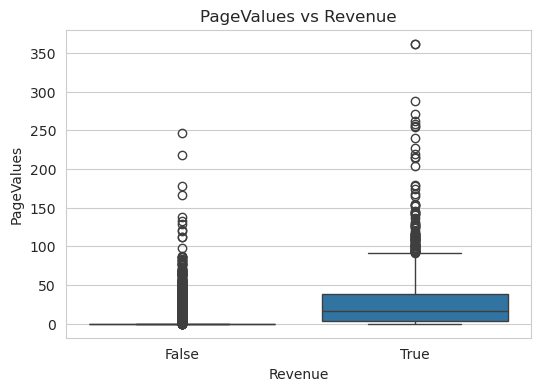

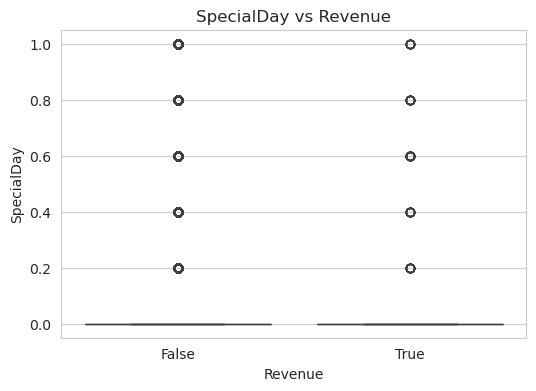

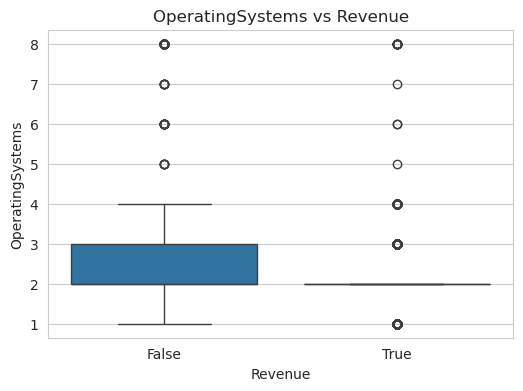

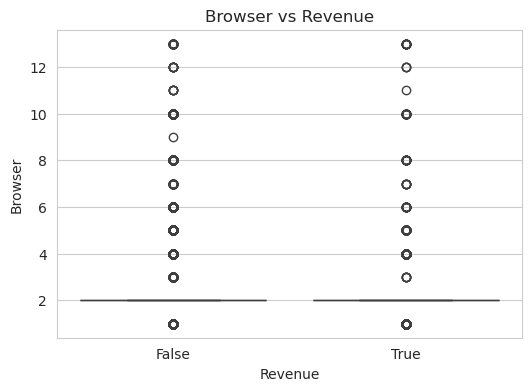

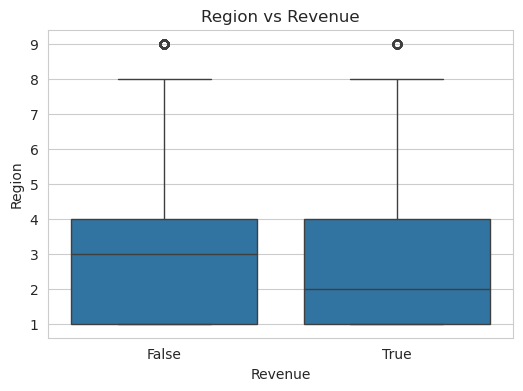

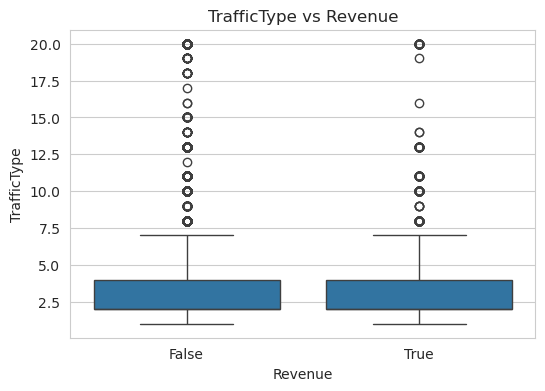

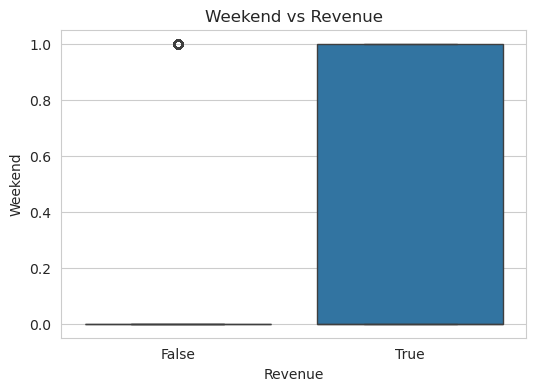

In [15]:
#Feature vs Target Analysis
for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Revenue", y=col, data=df)
    
    plt.title(f"{col} vs Revenue")
    plt.show()

Users who generate revenue generally have higher values for engagement
metrics such as PageValues and ProductRelated_Duration.

This suggests that deeper interaction with product pages strongly
influences purchase likelihood.

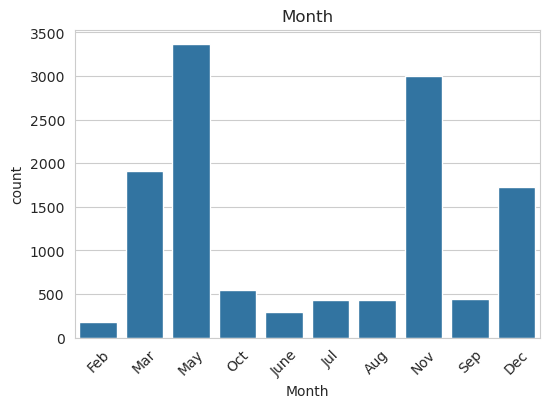

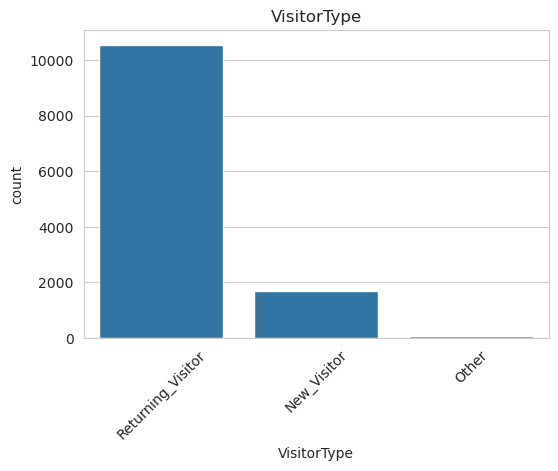

In [16]:
#Categorical Feature Analysis
for col in categorical_cols:
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    
    plt.title(col)
    plt.xticks(rotation=45)
    
    plt.show()

Categorical variables such as Month and VisitorType reveal patterns in
user behavior.

For example, returning visitors may show different purchase behavior
compared to new visitors. These variables may provide useful predictive
signals during modeling.

Key insights from exploratory analysis include:

1. The dataset is highly imbalanced (~85% non-purchase sessions).
2. Engagement metrics such as PageValues and ProductRelated_Duration
   strongly influence purchase likelihood.
3. High BounceRates and ExitRates are associated with lower conversion.
4. Several numerical features exhibit significant skewness.
5. Both behavioral metrics and session context features appear
   informative for predicting purchases.

These insights guide the modeling approach:
- Use evaluation metrics suited for imbalanced datasets.
- Apply appropriate encoding for categorical variables.
- Consider tree-based models that handle skewed feature distributions
  effectively.

Based on the insights from exploratory data analysis, the next step will
be building predictive models to estimate purchase likelihood.

The modeling pipeline will include:

• Train-test split  
• Encoding of categorical variables  
• Scaling of numerical features when required  
• Evaluation using ROC-AUC, Recall, and F1-score